# World Cup Schedules and Results

## Objective

In this notebook I want to create a dataset with the following structure:

- Columns: tournament_id, stage_name, group_stage, goals_against, goals_for, team_id, opponent_id, city_name, team_name, opponent_name, match_date, match_time, rest_days.
- Rows: All games in the 2010, 2014, 2018, and 2022 World Cup. That is 512 rows since there is 64 games per WC and we have 2 rows per game (one per team), hence: 64*4*2=512.

This dataset will be the bases for our training data to fit our regression model to estimate our rate parameter of our Poisson Distirbution.

## Ouput 

- `1.DataCleaning-R/Data/RDS/FullTeamGames.rds`

## Acknowledgments

I used data from The Fjelstul World Cup Database throught the R Package "worldcup". 
About The Fjelstul World Cup Database:
- Author: Joshua C. Fjelstul, Ph.D.
- Copyright: © 2023 Joshua C. Fjelstul, Ph.D.
- License: https://creativecommons.org/licenses/by-sa/4.0/legalcode
- GitHub: https://github.com/jfjelstul/worldcup

## Packages

In [13]:
library(tidyverse)
library(worldcup)
library(here)

## Hisotrical World Cup Records

In [14]:
FullTeamGames <- worldcup::team_appearances
head(FullTeamGames)
colnames(FullTeamGames)

key_id,tournament_id,tournament_name,match_id,match_name,stage_name,group_name,group_stage,knockout_stage,replayed,...,goals_against,goal_differential,extra_time,penalty_shootout,penalties_for,penalties_against,result,win,lose,draw
<int>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,...,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<dbl>,<dbl>,<dbl>
1,WC-1930,1930 FIFA Men's World Cup,M-1930-01,France vs Mexico,group stage,Group 1,1,0,0,...,1,3,0,0,0,0,win,1,0,0
2,WC-1930,1930 FIFA Men's World Cup,M-1930-01,France vs Mexico,group stage,Group 1,1,0,0,...,4,-3,0,0,0,0,lose,0,1,0
3,WC-1930,1930 FIFA Men's World Cup,M-1930-02,United States vs Belgium,group stage,Group 4,1,0,0,...,0,3,0,0,0,0,win,1,0,0
4,WC-1930,1930 FIFA Men's World Cup,M-1930-02,United States vs Belgium,group stage,Group 4,1,0,0,...,3,-3,0,0,0,0,lose,0,1,0
5,WC-1930,1930 FIFA Men's World Cup,M-1930-03,Yugoslavia vs Brazil,group stage,Group 2,1,0,0,...,1,1,0,0,0,0,win,1,0,0
6,WC-1930,1930 FIFA Men's World Cup,M-1930-03,Yugoslavia vs Brazil,group stage,Group 2,1,0,0,...,2,-1,0,0,0,0,lose,0,1,0


[1] "key_id"            "tournament_id"     "tournament_name"  
 [4] "match_id"          "match_name"        "stage_name"       
 [7] "group_name"        "group_stage"       "knockout_stage"   
[10] "replayed"          "replay"            "match_date"       
[13] "match_time"        "stadium_id"        "stadium_name"     
[16] "city_name"         "country_name"      "team_id"          
[19] "team_name"         "team_code"         "opponent_id"      
[22] "opponent_name"     "opponent_code"     "home_team"        
[25] "away_team"         "goals_for"         "goals_against"    
[28] "goal_differential" "extra_time"        "penalty_shootout" 
[31] "penalties_for"     "penalties_against" "result"           
[34] "win"               "lose"              "draw"

In [15]:
FullTeamGames <- FullTeamGames %>%  
    select(match_id, tournament_id, stage_name, group_stage, goals_against, goals_for, team_id, opponent_id, city_name, team_name, opponent_name, match_date, match_time)

dim(FullTeamGames)

[1] 2496   13

In [16]:
FullTeamGames <- FullTeamGames %>%
    filter(as.numeric(str_sub(tournament_id, -4)) >= 2010)

dim(FullTeamGames)

[1] 784  13

After filtering tournaments we still have more rows than expected. Lets inspect this.

In [17]:

FullTeamGames %>% 
    group_by(tournament_id) %>%
        summarize(games = sum(n()))

tournament_id,games
<chr>,<int>
WC-2010,128
WC-2011,64
WC-2014,128
WC-2015,104
WC-2018,128
WC-2019,104
WC-2022,128


The issue here is that we have Women's and Men's world cup data. For this particular dataset we're only interested in Men's world cups.

In [18]:
FullTeamGames <- FullTeamGames %>%
    filter(!(tournament_id %in% c("WC-2015", "WC-2019", "WC-2011")))

dim(FullTeamGames)

[1] 512  13

It might be of interest for our model to asses rest. I will add a variable of rest in days given by date-last_game_date.

In [19]:
set.seed(123)

FullTeamGames <- FullTeamGames %>%
    arrange(tournament_id, team_id, match_date, match_time) %>%
        group_by(tournament_id, team_id) %>%
            mutate(
                last_game_date = lag(match_date),
                rest_days = as.numeric(match_date - last_game_date)
            ) %>%
    ungroup()

FullTeamGames %>%
    select(tournament_id, team_name, opponent_name, match_date, last_game_date, rest_days) %>%
        slice_sample(n=10)



tournament_id,team_name,opponent_name,match_date,last_game_date,rest_days
<chr>,<chr>,<chr>,<date>,<date>,<dbl>
WC-2022,Croatia,Belgium,2022-12-01,2022-11-27,4
WC-2022,Netherlands,Qatar,2022-11-29,2022-11-25,4
WC-2014,Ecuador,Honduras,2014-06-20,2014-06-15,5
WC-2010,Brazil,Portugal,2010-06-25,2010-06-20,5
WC-2014,Germany,Argentina,2014-07-13,2014-07-08,5
WC-2022,England,Iran,2022-11-21,NA,NA
WC-2018,France,Denmark,2018-06-26,2018-06-21,5
WC-2010,United States,England,2010-06-12,NA,NA
WC-2018,England,Belgium,2018-06-28,2018-06-24,4


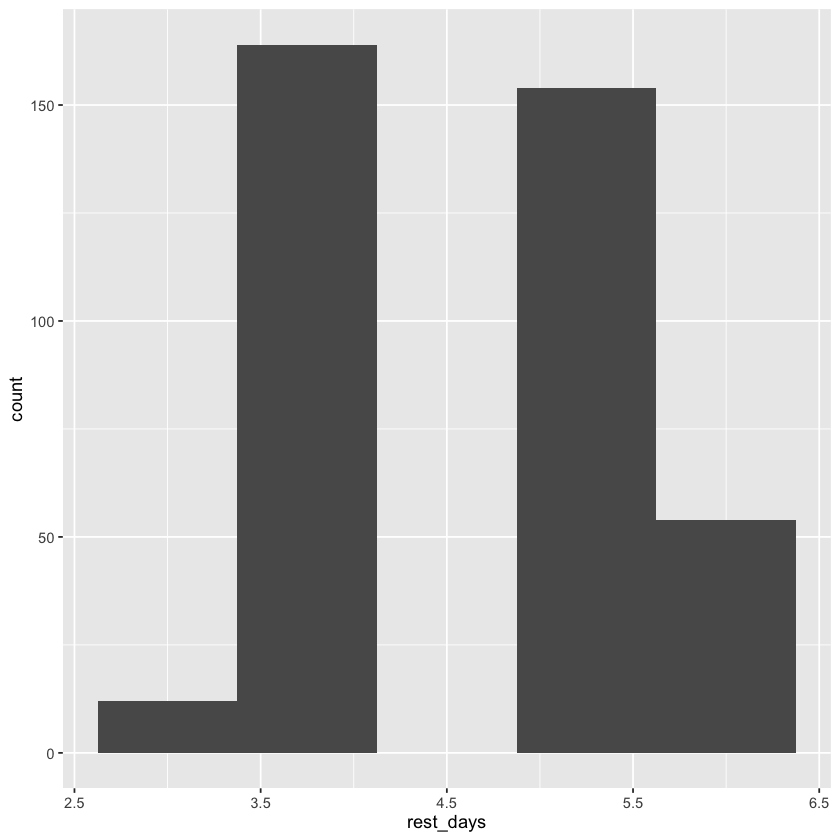

In [20]:
FullTeamGames %>% 
    drop_na(rest_days) %>%
        ggplot(aes(x=rest_days)) +
             geom_histogram(bins = 5)

In [21]:
FullTeamGames %>%
    group_by(rest_days) %>%
        summarize(count=sum(n()))

rest_days,count
<dbl>,<int>
3,12
4,164
5,154
6,54
NA,128


Since there's 32 teams per world and we're accoiunting for 4 world cups we'd expect 128 N/A. Each team should have one N/A per tournament (there first game in the tournament). I will assign. a value of 7 to all N/As since most teams play their last exhibition game at leats 7 days before the tournament stars.

In [22]:
FullTeamGames <- FullTeamGames %>%
    mutate(
        rest_days = if_else(is.na(rest_days), 7, rest_days)
    )

In [23]:
saveRDS(FullTeamGames, here("1.DataCleaning-R", "Data", "RDS", "FullTeamGames.rds"))